<a href="https://colab.research.google.com/github/abhishek18-blog/DataScience-and-ML/blob/main/HMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Model Parameters from your HMM slides
# Define the possible hidden states (Part-of-Speech tags)
states = ['Noun (N)', 'Modal (M)', 'Verb (V)']
# Define the possible observed words in the vocabulary
words = ['Mary', 'Jane', 'Will', 'Spot', 'Can', 'See', 'pat']

# Transition Probabilities (A) [cite: 166-184]
# This matrix represents P(state_t | state_{t-1})
# Rows: From State | Columns: To State
A = np.array([
    [1/9, 3/9, 1/9], # Probabilities from Noun (N) to N, M, V
    [1/4, 0.0, 3/4], # Probabilities from Modal (M) to N, M, V
    [1.0, 0.0, 0.0]  # Probabilities from Verb (V) to N, M, V
])

# Emission Probabilities (B) [cite: 101-127]
# This matrix represents P(word_t | state_t)
# Rows: States | Columns: Words
B = np.array([
    [4/9, 2/9, 1/9, 2/9, 0.0, 0.0, 0.0], # Emission probabilities for Noun (N) for each word
    [0.0, 0.0, 3/4, 0.0, 1/4, 0.0, 0.0], # Emission probabilities for Modal (M) for each word
    [0.0, 0.0, 0.0, 1/4, 0.0, 2/4, 1.0]  # Emission probabilities for Verb (V) for each word
])

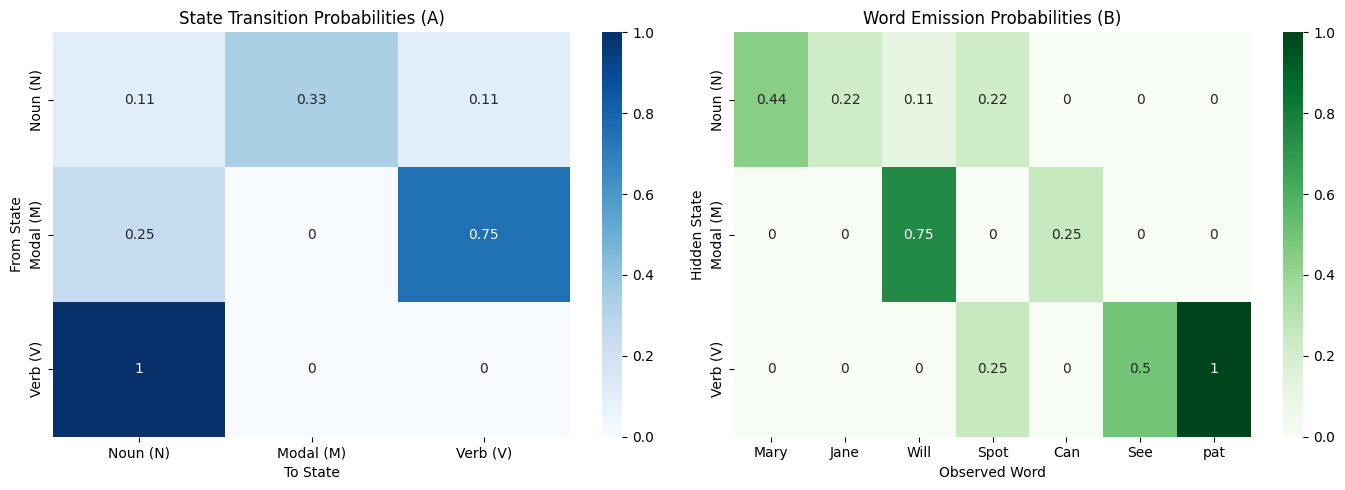

In [4]:
# 2. Visualization Functions
def plot_hmm_graphs():
    plt.figure(figsize=(14, 5))

    # Graph 1: Transition Matrix (A)
    # Shows: Probability of moving from one POS tag to another [cite: 15]
    plt.subplot(1, 2, 1) # Create a subplot for the transition matrix
    sns.heatmap(A, annot=True, xticklabels=states, yticklabels=states, cmap='Blues')
    plt.title('State Transition Probabilities (A)')
    plt.xlabel('To State')
    plt.ylabel('From State')

    # Graph 2: Emission Matrix (B)
    # Shows: Probability of a State "emitting" a specific Word [cite: 17]
    plt.subplot(1, 2, 2) # Create a subplot for the emission matrix
    sns.heatmap(B, annot=True, xticklabels=words, yticklabels=states, cmap='Greens')
    plt.title('Word Emission Probabilities (B)')
    plt.xlabel('Observed Word')
    plt.ylabel('Hidden State')

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

# Run the visualization
plot_hmm_graphs()

In [5]:
# 3. Define Initial State Probabilities (pi) and Word to Index Mapping
# Initial State Probabilities (pi) - P(state_0) [cite: 30]
# Assumed uniform distribution as an example. Adjust if you have specific starting state probabilities.
pi = np.array([1/3, 1/3, 1/3]) # Equal probability for starting in Noun, Modal, or Verb

# Create a mapping from words to their indices for easier lookup in the B matrix
word_to_idx = {word: i for i, word in enumerate(words)}

print("Initial State Probabilities (pi):")
print(pi)
print("\nWord to Index Mapping:")
print(word_to_idx)

Initial State Probabilities (pi):
[0.33333333 0.33333333 0.33333333]

Word to Index Mapping:
{'Mary': 0, 'Jane': 1, 'Will': 2, 'Spot': 3, 'Can': 4, 'See': 5, 'pat': 6}


In [6]:
# 4. Implement the Forward Algorithm
def forward_algorithm(obs_seq, pi, A, B):
    T = len(obs_seq) # Length of the observation sequence
    N = len(pi)      # Number of hidden states
    alpha = np.zeros((T, N))

    # Step 1: Initialization [cite: 31]
    first_word = obs_seq[0]
    # Check if the word is in the vocabulary
    if first_word not in word_to_idx:
        print(f"Warning: '{first_word}' not in vocabulary. Probability will be 0.")
        return 0.0 # Cannot compute if first word is unknown

    first_word_idx = word_to_idx[first_word]
    for i in range(N):
        alpha[0, i] = pi[i] * B[i, first_word_idx]

    # Step 2: Recursion [cite: 31, 32]
    for t in range(1, T):
        current_word = obs_seq[t]
        # Check if the word is in the vocabulary
        if current_word not in word_to_idx:
            print(f"Warning: '{current_word}' not in vocabulary. Probability will be 0.")
            return 0.0 # Cannot compute if an observed word is unknown

        word_idx = word_to_idx[current_word]
        for j in range(N):
            # Sum of (previous alpha * transition) * emission
            sum_prev = sum(alpha[t-1, i] * A[i, j] for i in range(N))
            alpha[t, j] = sum_prev * B[j, word_idx]

    # Step 3: Termination (Total Probability) [cite: 32]
    # The probability of the observation sequence is the sum of the last row of alpha
    return np.sum(alpha[T-1, :])

In [7]:
# 5. Evaluate the Forward Algorithm
# Test with the sentence from your slide [cite: 187]
test_sentence = ['Will', 'Can', 'Spot', 'Mary']
prob = forward_algorithm(test_sentence, pi, A, B)

print(f"The probability of the sequence {test_sentence} is: {prob:.10f}")

# Example with a word not in vocabulary
# test_sentence_unknown = ['Will', 'UnknownWord', 'Spot', 'Mary']
# prob_unknown = forward_algorithm(test_sentence_unknown, pi, A, B)
# print(f"The probability of the sequence {test_sentence_unknown} is: {prob_unknown:.10f}")

The probability of the sequence ['Will', 'Can', 'Spot', 'Mary'] is: 0.0002656692


# The Forward Algorithm

 The Forward Algorithm is a dynamic programming algorithm used to calculate the probability of observing a particular sequence of observations (words, in our case) given a Hidden Markov Model. It efficiently computes the sum of probabilities of all possible hidden state sequences that could have generated the observed sequence.

### How it works:

1.  **Initialization:** It starts by calculating the probability of being in each hidden state at the first time step, considering the initial state probabilities (`pi`) and the emission probability of the first observed word.
2.  **Recursion:** For each subsequent time step, it iteratively calculates the probability of being in each hidden state, taking into account the probabilities from the previous time step, the transition probabilities between states (`A`), and the emission probability of the current observed word (`B`).
3.  **Termination:** Finally, the probability of the entire observed sequence is the sum of the probabilities of being in any hidden state at the last time step.